# Normal Distribution — Concepts, Visualization, and a Real-Life Case Study

## Learning objectives
By the end of this notebook, you should be able to:

- Explain what a normal distribution is.
- Understand the **mean**, **standard deviation**, and **z-score**.
- Interpret the **68–95–99.7 rule**.
- Calculate probabilities using a normal distribution.
- Apply the normal distribution to a real-life case study.

> **Note:** The case-study data in this notebook are **synthetic** (created for learning), but the situation is based on a common real-world use of statistics: analyzing human heights.


## 1. What is a normal distribution?

A **normal distribution** is a continuous probability distribution with a characteristic **bell-shaped, symmetric curve**.

Important properties:

1. The curve is symmetric around the mean.
2. **Mean = Median = Mode** for a perfectly normal distribution.
3. Most observations are close to the mean.
4. Observations farther from the mean become less common.
5. The total area under the curve is **1 (100%)**.

The probability density function is:

\[
f(x)=\frac{1}{\sigma\sqrt{2\pi}}
e^{-\frac{(x-\mu)^2}{2\sigma^2}}
\]

where:

- \(\mu\) = population mean
- \(\sigma\) = population standard deviation
- \(x\) = observed value

You do not need to memorize the formula to understand the basic idea: **the mean determines the center, while the standard deviation determines how spread out the curve is.**


## 2. Mean and standard deviation

### Mean

The mean is the arithmetic average:

\[
\bar{x}=\frac{x_1+x_2+\cdots+x_n}{n}
\]

### Standard deviation

Standard deviation measures how far observations tend to be from the mean.

- **Small standard deviation:** values are tightly clustered.
- **Large standard deviation:** values are more spread out.

For a normal distribution, these two quantities completely determine the shape of the distribution.


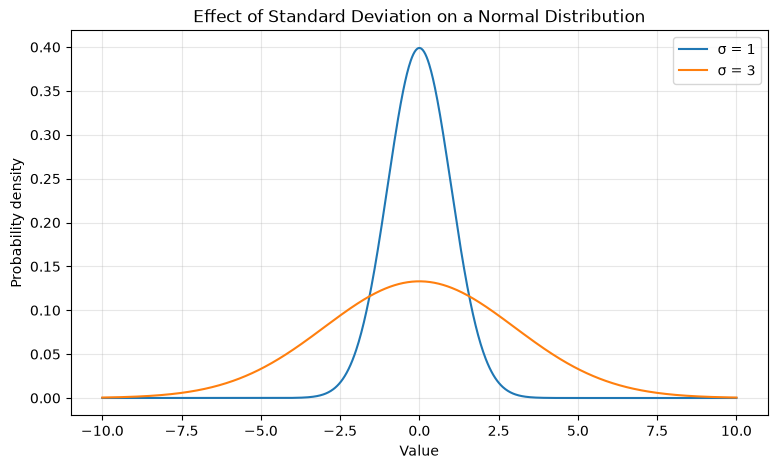

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Create two normal distributions with the same mean but different standard deviations
x = np.linspace(-10, 10, 1000)

mu = 0
sigma_small = 1
sigma_large = 3

pdf_small = (1/(sigma_small*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma_small)**2)
pdf_large = (1/(sigma_large*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma_large)**2)

plt.figure(figsize=(9, 5))
plt.plot(x, pdf_small, label="σ = 1")
plt.plot(x, pdf_large, label="σ = 3")
plt.title("Effect of Standard Deviation on a Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Probability density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 3. The 68–95–99.7 rule

For a normal distribution:

- About **68%** of observations lie within **1 standard deviation** of the mean.
- About **95%** lie within **2 standard deviations**.
- About **99.7%** lie within **3 standard deviations**.

For example, if exam scores are approximately normal with:

\[
\mu=70,\quad \sigma=10
\]

then approximately:

- 68% are between 60 and 80.
- 95% are between 50 and 90.
- 99.7% are between 40 and 100.


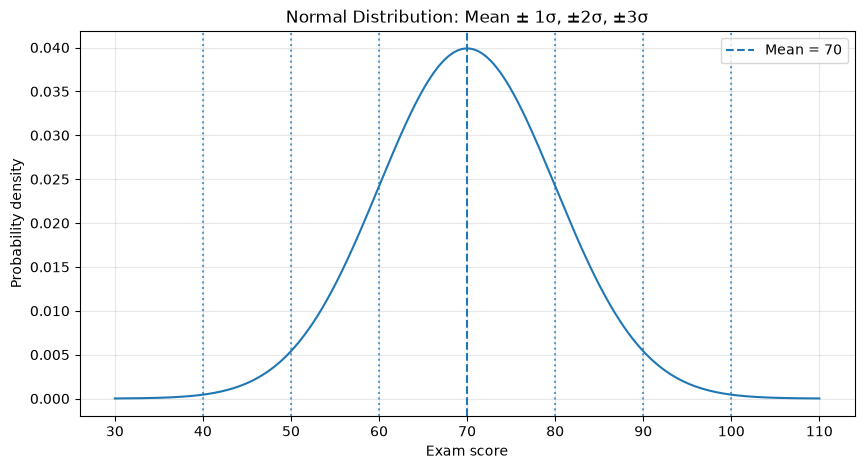

In [2]:
# Visualize the 68–95–99.7 rule
from scipy.stats import norm

mu = 70
sigma = 10
x = np.linspace(30, 110, 1000)
y = norm.pdf(x, mu, sigma)

plt.figure(figsize=(10, 5))
plt.plot(x, y)
plt.axvline(mu, linestyle="--", label="Mean = 70")

for k in [-3, -2, -1, 1, 2, 3]:
    plt.axvline(mu + k*sigma, linestyle=":", alpha=0.7)

plt.title("Normal Distribution: Mean ± 1σ, ±2σ, ±3σ")
plt.xlabel("Exam score")
plt.ylabel("Probability density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 4. The z-score

A **z-score** tells us how many standard deviations an observation is away from the mean.

\[
z=\frac{x-\mu}{\sigma}
\]

Interpretation:

- \(z=0\): exactly at the mean.
- \(z=1\): one standard deviation above the mean.
- \(z=-2\): two standard deviations below the mean.

### Example

If the mean exam score is 70 and the standard deviation is 10, what is the z-score of a student who scored 85?

\[
z=\frac{85-70}{10}=1.5
\]

So the score is **1.5 standard deviations above the mean**.


In [3]:
from scipy.stats import norm

mu = 70
sigma = 10
score = 85

z = (score - mu) / sigma
percentile = norm.cdf(z) * 100

print(f"z-score: {z:.2f}")
print(f"Approximate percentile: {percentile:.2f}%")


z-score: 1.50
Approximate percentile: 93.32%


# 5. Real-Life Case Study: Human Heights

### Scenario

A school wants to understand the distribution of student heights for planning activities such as sports equipment, uniforms, and classroom seating.

We will generate a **synthetic sample of 1,000 student heights** using a normal distribution with:

- Mean height = **165 cm**
- Standard deviation = **7 cm**

This is a teaching example, not a claim about the actual height distribution of a particular school or population.


In [4]:
# Generate synthetic height data
np.random.seed(42)

heights = np.random.normal(loc=165, scale=7, size=1000)

print(f"Sample mean: {heights.mean():.2f} cm")
print(f"Sample standard deviation: {heights.std(ddof=1):.2f} cm")
print(f"Minimum: {heights.min():.2f} cm")
print(f"Maximum: {heights.max():.2f} cm")


Sample mean: 165.14 cm
Sample standard deviation: 6.85 cm
Minimum: 142.31 cm
Maximum: 191.97 cm


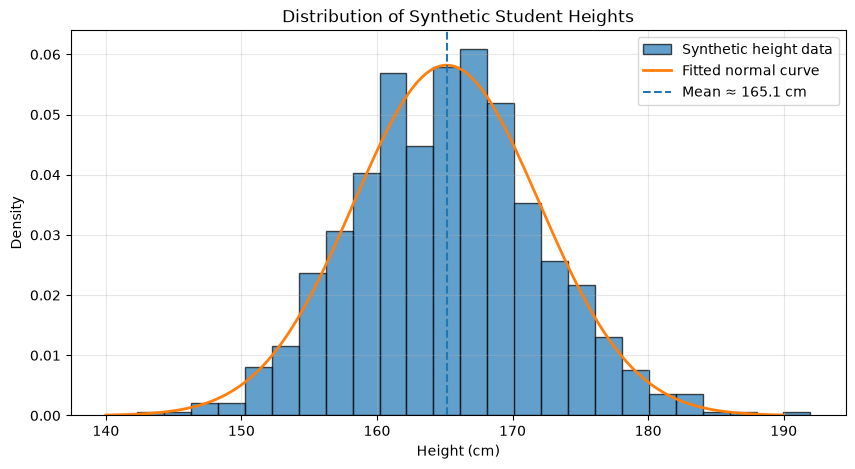

In [5]:
# Histogram with a fitted normal curve
mu_sample = heights.mean()
sigma_sample = heights.std(ddof=1)

x = np.linspace(140, 190, 500)
normal_curve = norm.pdf(x, mu_sample, sigma_sample)

plt.figure(figsize=(10, 5))
plt.hist(heights, bins=25, density=True, alpha=0.7, edgecolor="black", label="Synthetic height data")
plt.plot(x, normal_curve, linewidth=2, label="Fitted normal curve")
plt.axvline(mu_sample, linestyle="--", label=f"Mean ≈ {mu_sample:.1f} cm")

plt.title("Distribution of Synthetic Student Heights")
plt.xlabel("Height (cm)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 6. Case-study question 1: What proportion are between 158 cm and 172 cm?

Using the model:

\[
X\sim N(165,7^2)
\]

we want:

\[
P(158\leq X\leq172)
\]

Convert both values to z-scores:

\[
z_1=\frac{158-165}{7}=-1
\]

\[
z_2=\frac{172-165}{7}=1
\]

Therefore, this is approximately the area between **-1 and +1 standard deviations**, which should be close to **68%**.


In [6]:
lower = 158
upper = 172

prob_between = norm.cdf(upper, loc=165, scale=7) - norm.cdf(lower, loc=165, scale=7)

print(f"P({lower} ≤ X ≤ {upper}) = {prob_between:.4f}")
print(f"Percentage ≈ {prob_between*100:.2f}%")


P(158 ≤ X ≤ 172) = 0.6827
Percentage ≈ 68.27%


## 7. Case-study question 2: How many students are taller than 175 cm?

We want:

\[
P(X>175)
\]

First calculate the z-score:

\[
z=\frac{175-165}{7}\approx1.43
\]

Then calculate the area to the right of 175 cm.

This can help a school estimate how many students might need larger-size uniforms or equipment.


In [7]:
height_cutoff = 175

z = (height_cutoff - 165) / 7
prob_taller = 1 - norm.cdf(height_cutoff, loc=165, scale=7)
expected_students = prob_taller * 1000

print(f"z-score = {z:.2f}")
print(f"Probability of being taller than {height_cutoff} cm = {prob_taller:.4f}")
print(f"Percentage ≈ {prob_taller*100:.2f}%")
print(f"Expected number in a group of 1,000 ≈ {expected_students:.0f} students")


z-score = 1.43
Probability of being taller than 175 cm = 0.0766
Percentage ≈ 7.66%
Expected number in a group of 1,000 ≈ 77 students


## 8. Case-study question 3: What height represents the 90th percentile?

A percentile tells us the value below which a certain percentage of observations fall.

For the 90th percentile:

\[
P(X\leq x)=0.90
\]

We can use the inverse normal function to find the corresponding height.


In [8]:
percentile_90 = norm.ppf(0.90, loc=165, scale=7)

print(f"90th percentile height ≈ {percentile_90:.2f} cm")


90th percentile height ≈ 173.97 cm


## 9. A practical interpretation

Suppose the 90th percentile is approximately 174 cm.

That means:

> About 90% of students in the modeled population would be expected to have a height at or below approximately 174 cm, while about 10% would be taller.

This is a **probabilistic statement**, not a prediction about any individual student.

### Important assumptions

The calculations above assume that:

- The height distribution is reasonably modeled by a normal distribution.
- The chosen mean and standard deviation are appropriate.
- Observations are representative of the population of interest.

Real datasets may not be perfectly normal, so it is important to inspect the data rather than automatically assuming normality.


# 10. Key Takeaways

### Remember these five ideas:

1. **Normal distribution** → symmetric, bell-shaped distribution.
2. **Mean (μ)** → center of the distribution.
3. **Standard deviation (σ)** → spread of the distribution.
4. **Z-score** → tells how many standard deviations a value is from the mean.
5. **68–95–99.7 rule** → useful shortcut for understanding probabilities.

### Formula to remember

\[
\boxed{z=\frac{x-\mu}{\sigma}}
\]

### Where normal distributions are used

Normal-distribution models are commonly used in statistical analysis of measurements such as heights, test scores, measurement errors, manufacturing variation, and other approximately bell-shaped data.

**Next step:** Try changing the mean, standard deviation, or sample size in the code cells and observe how the distribution changes.
